# Project: Disease detection in corn crops

### Objectives

This project aims to use neural networks (CNNs) to detect different diseases in corn crops.

* Analyze the distribution of instances in the dataset (training and validation).
* Pre-process and divide the dataset correctly.
* Apply normalization to the images.
* Apply data augmentation to expand the training and avoid overfitting.
* Use transfer learning to extract features more robustly.
* Develop a network to classify diseases using advanced techniques.
* Test and validate the model for production.

### Relevance for Agriculture

The development of an automated system for plant disease classification is highly relevant to the agricultural sector for several practical and economic reasons:

- **Complexity of studying pathogens:** Fungi and bacteria that attack plants have complex life cycles and different stages, each requiring specific attention. Understanding the full cycle of a fungus is essential for effective disease management.

- **Prevention and remediation:** Proper disease management involves two critical moments — prevention and remediation. Prevention, when done correctly, is more cost-effective and efficient than treatment after the disease has manifested.

- **Reliable diagnostics:** Farmers often face incorrect or uncertain diagnoses, which can lead to trial-and-error in treatment application, increasing costs and risks to the crop.

- **Importance of early detection:** Prevention is cheaper and more effective, so identifying the early stages of diseases becomes crucial to avoid progression and productivity loss.

- **Avoiding phytotoxicity:** Improper use of agrochemicals can cause phytotoxicity, harming the plants. Knowing exactly when and how to apply treatments (spray volume, droplet size, coverage proportion) helps protect both the plants and the environment.

- **Optimization of agrochemical use:** For every curative application needed, often one or more preventive applications could have avoided the problem. This makes the process more sustainable and economical.

In summary, an automated classification system can assist farmers in quickly identifying the problem, choosing the right timing and treatment method, saving resources, reducing risks, and increasing agricultural productivity.

### Author

<a href='https://www.linkedin.com/in/pedro-henrique-amorim-de-azevedo/' target='_blank'>Pedro Henrique Amorim de Azevedo</a>


### Install and load necessary libraries

In [ ]:
!pip install -q numpy 
!pip install -q scipy
!pip install -q pandas
!pip install -q seaborn
!pip install -q matplotlib
!pip install -q tensorflow[and-cuda]
!pip install -q pillow 
!pip install -q scikit-learn

In [1]:
%matplotlib inline

import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU, Conv2D
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Multiply
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix

from PIL import Image

import warnings
warnings.simplefilter('ignore', FutureWarning)

2025-05-26 15:38:48.255046: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-26 15:38:48.405379: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-26 15:38:48.448017: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-26 15:38:48.734733: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-26 15:38:50.295390: W tensorflow/compiler/tf2

### Optimizations

We will use the `set_memory_growth` method to enable dynamic GPU VRAM allocation.

In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        details = tf.config.experimental.get_device_details(gpus[0])
        print("GPU:", details.get("device_name", "Unknown"))

        # Definir alocação dinâmica
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
    else:
        print("Dynamic VRAM allocation successfully enabled.")

GPU: NVIDIA GeForce RTX 3060
Dynamic VRAM allocation successfully enabled.


## Dataset Description  

This dataset contains images of corn leaves classified into four categories:  

<div style="display: flex; justify-content: center;">  
	<table style="border-collapse: collapse; width: 60%; text-align: center; font-size: 16px;">  
		<tr style="background-color: #f2f2f2;">  
			<th style="border: 1px solid #ddd; padding: 10px;">Class</th>  
			<th style="border: 1px solid #ddd; padding: 10px;">Description</th>  
		</tr>  
		<tr>  
			<td style="border: 1px solid #ddd; padding: 10px;">healthy</td>  
			<td style="border: 1px solid #ddd; padding: 10px;">Corn leaves with no visible signs of disease.</td>  
		</tr>  
		<tr style="background-color: #f9f9f9;">  
			<td style="border: 1px solid #ddd; padding: 10px;">cercospora</td>  
			<td style="border: 1px solid #ddd; padding: 10px;">Gray Leaf Spot (*Cercospora zeae-maydis*).</td>  
		</tr>  
		<tr>  
			<td style="border: 1px solid #ddd; padding: 10px;">rust</td>  
			<td style="border: 1px solid #ddd; padding: 10px;">Common Rust (*Puccinia sorghi* or *Puccinia polysora*).</td>  
		</tr>  
		<tr style="background-color: #f9f9f9;">  
			<td style="border: 1px solid #ddd; padding: 10px;">northern_leaf_blight</td>  
			<td style="border: 1px solid #ddd; padding: 10px;">Northern Leaf Blight (*Exserohilum turcicum*).</td>  
		</tr>  
	</table>  
</div>  


### Loading the dataset

We will use the folder structure itself to define the classes of the training instances.

In [3]:
dataset_path = 'datasets/'
train_path = os.path.join(dataset_path, 'train')
val_path = os.path.join(dataset_path, 'val')

train_classes = os.listdir(train_path)
val_classes = os.listdir(val_path)

print('Training folder: ', train_classes)
print('Validation folder: ', val_classes)

Training folder:  ['northern_leaf_blight', 'healthy', 'rust', 'cercospora']
Validation folder:  ['northern_leaf_blight', 'healthy', 'rust', 'cercospora']


### Checking class distribution

For training to be as effective as possible, we need to make sure that the dataset is well distributed among the classes. Otherwise, our model may be biased.

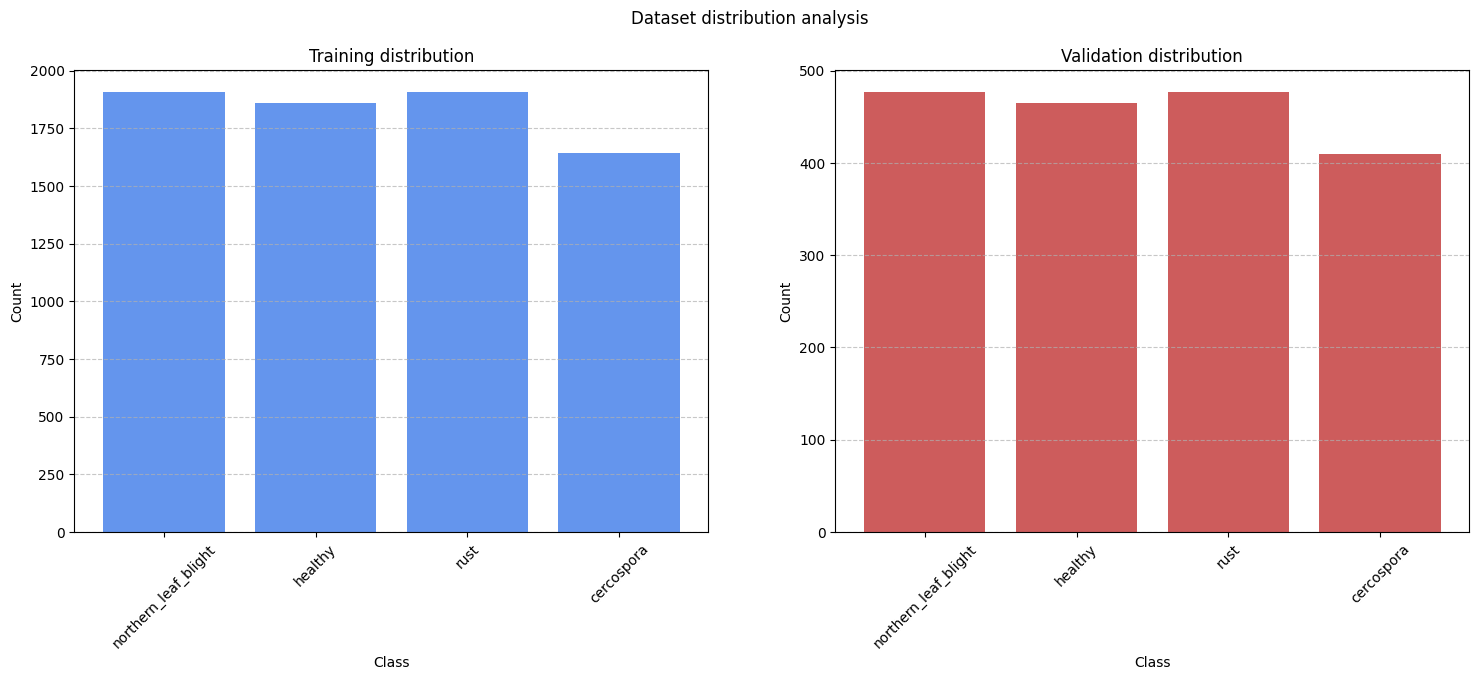

In [4]:
train_distribution = {}
for class_path in train_classes:
	_, _, files = next(os.walk(os.path.join(train_path, class_path)))
	train_distribution[class_path] = len(files)

val_distribution = {}
for class_path in val_classes:
	_, _, files = next(os.walk(os.path.join(val_path, class_path)))
	val_distribution[class_path] = len(files)


plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
plt.bar(train_distribution.keys(), train_distribution.values(), color='cornflowerblue')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Training distribution')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.bar(val_distribution.keys(), val_distribution.values(), color='indianred')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Validation distribution')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Dataset distribution analysis')
plt.show();

### Analyzing samples from the training sets

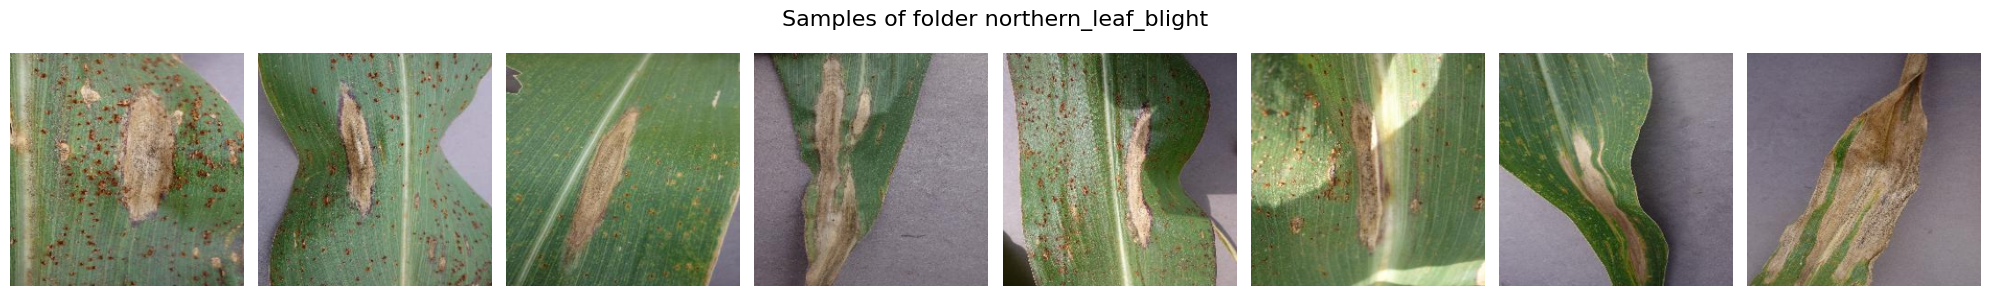

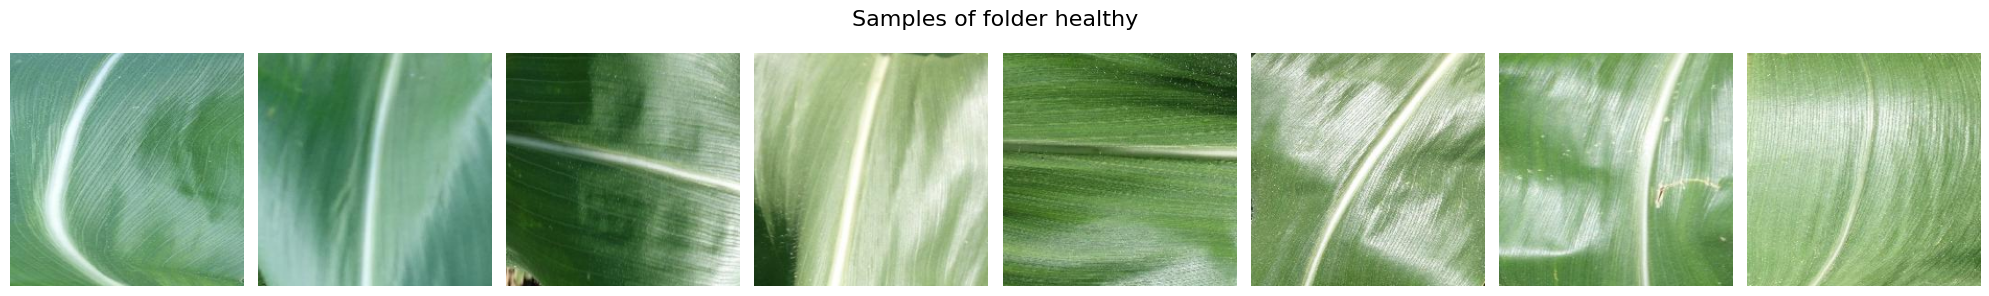

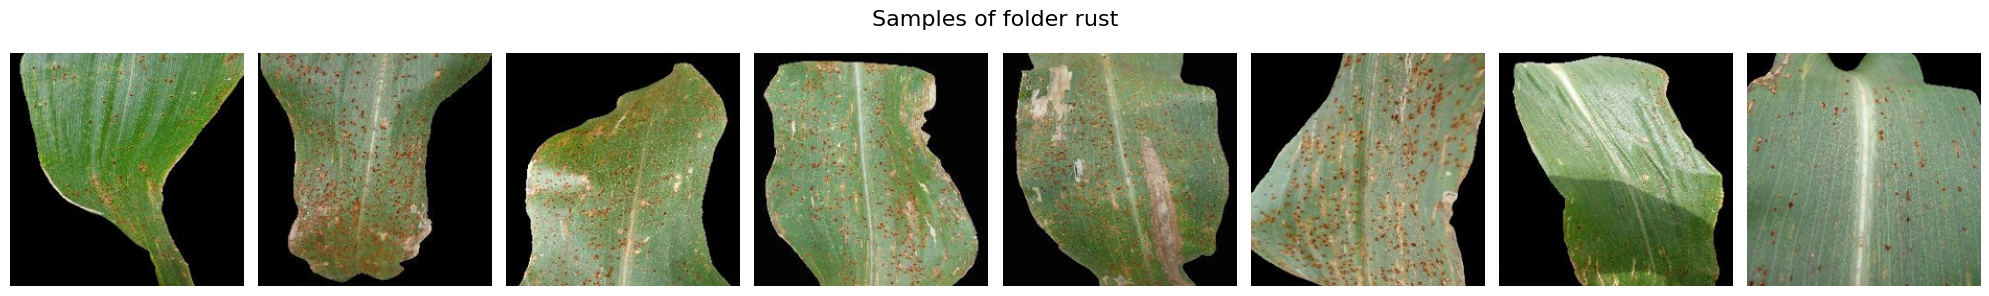

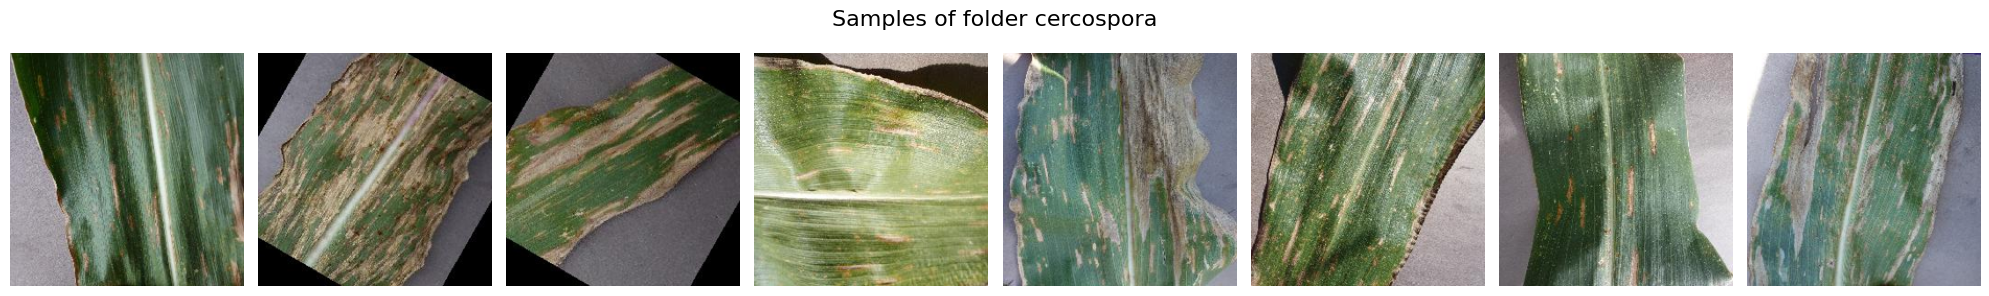

In [5]:
def plot_dataset_samples(data_class: str, num_images=8):
	selected_images = []
	class_path = os.path.join(train_path, data_class)

	for _ in range(num_images):
		image_choice = random.choice(os.listdir(class_path))  # Escolhe uma imagem aleatória
		image_path = os.path.join(class_path, image_choice)
		selected_images.append(image_path)

	fig, axes = plt.subplots(1, num_images, figsize=(20, 4))

	for i, image_path in enumerate(selected_images):
		img = Image.open(image_path)  # Abrir a imagem
		img = img.resize((224, 224))  # Redimensionar para manter o padrão
		axes[i].imshow(img)
		axes[i].axis('off')

	plt.suptitle(f'Samples of folder {data_class}', fontsize=16)
	plt.tight_layout(rect=[0, 0, 1, 1.25])
	plt.show()


for train_class in train_classes:
	plot_dataset_samples(train_class)

# Creating the neural network

### Using Transfer Learning

To accelerate the training of the final model, we will use Keras' Functional API and transfer learning with a pre-trained VGG16 network, which has already undergone extensive training on the ImageNet dataset. Therefore, this network is capable of performing robust feature extraction, which will support our model development.

This strategic decision saves time, computational resources, and the need for investing in large datasets.

### Leaky ReLU

Typically, the ReLU activation function is used in most cases. However, the "dying ReLU" problem can prevent the network from learning effectively. Therefore, we will test the Leaky ReLU function, which mitigates this issue by allowing small gradients to flow even when the unit is not active.

This can be useful for capturing finer details.

### 'he_normal' Initialization

By default, Keras initializes the weights of `Dense()` layers using the `glorot_uniform` initializer. However, to improve gradient propagation through the network, we will use `he_normal`. This initializer is optimized for use with ReLU and Leaky ReLU activations, helping the network learn better and avoid getting stuck in local minima due to vanishing gradients.

### Parallel Pooling and Attention Mechanism

If we only use a `Flatten` layer to merge the network outputs, it may not adequately capture the necessary feature importance. After some research and experimentation, I found that using a `GlobalAveragePooling2D` layer at the output is a good solution. However, since these diseases have similar characteristics such as shape and color, it may be worthwhile to try an approach with two parallel pooling layers that detect different features, followed by an attention layer to assign weights to the most important pixels.

To understand this approach, let's consider analyzing a corn leaf:

1. The parallel pooling layers capture:
   * The average number of pustules (AvgPool)
   * The areas with the highest concentration (MaxPool)

2. The attention mechanism:
   * Assigns high weights to orange pustules
   * Assigns low weights to healthy green areas


In [6]:
IMG_SIZE = (224, 224) 
BATCH_SIZE = 32
EPOCHS = 80
LEARNING_RATE = 1e-4
PATIENCE = 15

# Load the base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))

# Freeze all layers except the last 4 for better fine-tuning (try 8)
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Two parallel pooling layers to capture different features
x1 = GlobalAveragePooling2D()(base_model.output)  # Captures average intensity
x2 = GlobalMaxPooling2D()(base_model.output)      # Captures intensity peaks
x = Concatenate()([x1, x2])  # Combines the pooling layers

# Generates weights between 0 and 1
attention = Dense(1024, activation='sigmoid', kernel_regularizer=l2(0.01))(x)
x = Multiply()([x, attention])  # Multiplies features by the generated weights

# With L2 regularization, we penalize very high weights. This reduces the dominance of certain neurons.
# It makes the model less dependent on specific features and encourages it to leverage all features.
x = Dense(1024, kernel_initializer='he_normal', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.2)(x) 
x = Dropout(0.5)(x)

x = Dense(512, kernel_initializer='he_normal', kernel_regularizer=l2(0.01))(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.2)(x)
x = Dropout(0.4)(x)

# Increase L2 to encourage a more balanced confidence
x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2(0.02))(x)
x = BatchNormalization()(x)
# A higher alpha here allows more negative features to pass, serving as regularization.
# It helps to better activate the correct neurons by making them more sensitive to variations.
x = LeakyReLU(alpha=0.3)(x)  
x = Dropout(0.3)(x)

output = Dense(4, activation='softmax', kernel_initializer='glorot_uniform')(x)

model = Model(inputs=base_model.input, outputs=output)

# Optimizer with weight decay
optimizer = Adam(learning_rate=LEARNING_RATE, weight_decay=1e-5)  # weight_decay for overall regularization
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy', 'AUC'])

# Print model summary
model.summary()


/home/pedro/anaconda3/envs/intellisis/lib/python3.9/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer_1[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 17,478,212 (66.67 MB)

 Trainable params: 9,839,364 (37.53 MB)

 Non-trainable params: 7,638,848 (29.14 MB)

### Data augmentation

The more instances of each class available for model training, the better the model's ability to generalize.

We will instantiate an ImageDataGenerator to synthetically increase our dataset. It works by generating, at each training epoch, a synthetic image with different properties such as rotation, horizontal or vertical flipping, shifting, among others.

This means that at each training epoch, the model will see the same image in a different way, as if it were the first time. This helps prevent overfitting and improves generalization capability, especially when working with smaller datasets.

In [7]:
train_datagen = ImageDataGenerator(
	rescale=1./255,
	rotation_range=45,
	width_shift_range=0.25,
	height_shift_range=0.25,
	shear_range=0.25,
	zoom_range=0.25,
	horizontal_flip=True,
	vertical_flip=True,
	brightness_range=[0.7, 1.3],
	fill_mode='nearest',
	channel_shift_range=20.0
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
def load_images(directory, datagen):
    print(f'Loading {directory}')
    classes = os.listdir(directory)
    
    # Map class names to an index
    class_idx = { class_name: idx for idx, class_name in enumerate(classes) }
    
    # Debug
    # print(class_idx)
    
    image_paths = []
    labels = []
    
    for class_name in classes:
        class_folder_path = os.path.join(directory, class_name)
        
        # List all files in the class folder
        for filename in os.listdir(class_folder_path):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG')):
                full_image_path = os.path.join(class_folder_path, filename)
                image_paths.append(full_image_path)
                labels.append(class_idx[class_name])        
    
    # Load and preprocess all images
    loaded_images = []
    for img_path in image_paths:
        img = load_img(img_path, target_size=IMG_SIZE)
        # Add RGB channels, i.e., (*IMG_SIZE, 3)
        img_array = img_to_array(img)
        loaded_images.append(img_array)

    images_array = np.array(loaded_images)
    
    # Convert labels to one-hot encoding
    labels_array = np.array(labels)
    one_hot_labels = to_categorical(labels_array, num_classes=len(classes))
    
    data_generator = datagen.flow(
        images_array, 
        one_hot_labels, 
        batch_size=BATCH_SIZE, 
        shuffle=True
    )
    
    return data_generator

# Load the data
train_generator = load_images(train_path, train_datagen)
validation_generator = load_images(val_path, val_datagen)


Loading datasets/train
Loading datasets/val


### Training the model

In [22]:
# Callbacks
callbacks = [
	EarlyStopping(monitor='val_accuracy', patience=PATIENCE, mode='max', restore_best_weights=True, verbose=1),
	ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=PATIENCE//3, min_lr=1e-6, verbose=1),
	ModelCheckpoint(os.path.join('models', 'classificador_checkpoint.keras'), monitor='val_accuracy', save_best_only=True, mode='max')
]

history = model.fit(
	train_generator,
	steps_per_epoch=len(train_generator),
	epochs=EPOCHS,
	validation_data=validation_generator,
	validation_steps=len(validation_generator),
	callbacks=callbacks,
	verbose=1
)


Epoch 1/80
229/229 ━━━━━━━━━━━━━━━━━━━━ 109s 445ms/step - AUC: 0.9163 - accuracy: 0.7351 - loss: 46.2843 - val_AUC: 0.9933 - val_accuracy: 0.9431 - val_loss: 31.2800 - learning_rate: 1.0000e-04
Epoch 2/80
229/229 ━━━━━━━━━━━━━━━━━━━━ 89s 390ms/step - AUC: 0.9945 - accuracy: 0.9427 - loss: 27.7329 - val_AUC: 0.9978 - val_accuracy: 0.9623 - val_loss: 18.9623 - learning_rate: 1.0000e-04
Epoch 3/80
229/229 ━━━━━━━━━━━━━━━━━━━━ 87s 381ms/step - AUC: 0.9963 - accuracy: 0.9526 - loss: 16.9153 - val_AUC: 0.9971 - val_accuracy: 0.9557 - val_loss: 11.7278 - learning_rate: 1.0000e-04
Epoch 4/80
229/229 ━━━━━━━━━━━━━━━━━━━━ 88s 385ms/step - AUC: 0.9965 - accuracy: 0.9570 - loss: 10.4802 - val_AUC: 0.9983 - val_accuracy: 0.9694 - val_loss: 7.3134 - learning_rate: 1.0000e-04
Epoch 5/80
229/229 ━━━━━━━━━━━━━━━━━━━━ 89s 387ms/step - AUC: 0.9968 - accuracy: 0.9561 - loss: 6.5839 - val_AUC: 0.9928 - val_accuracy: 0.9251 - val_loss: 4.7555 - learning_rate: 1.0000e-04
Epoch 6/80
229/229 ━━━━━━━━━━━━━━━━━━

### Retrieving the best model

Sometimes `EarlyStopping` may not kick in and retrieve the best weights. Therefore, let's load the best model saved by `ModelCheckpoint` and evaluate it.

In [23]:
best_model = load_model('models/classificador_checkpoint.keras')

eval = best_model.evaluate(validation_generator)
eval
#print(f'Validação:\n  - Perda: {val_loss}\n  - Acurácia: {val_acc}')}

58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - AUC: 0.9995 - accuracy: 0.9913 - loss: 0.0416


[0.043369490653276443, 0.9923455715179443, 0.9992583990097046]

### Evaluating the model

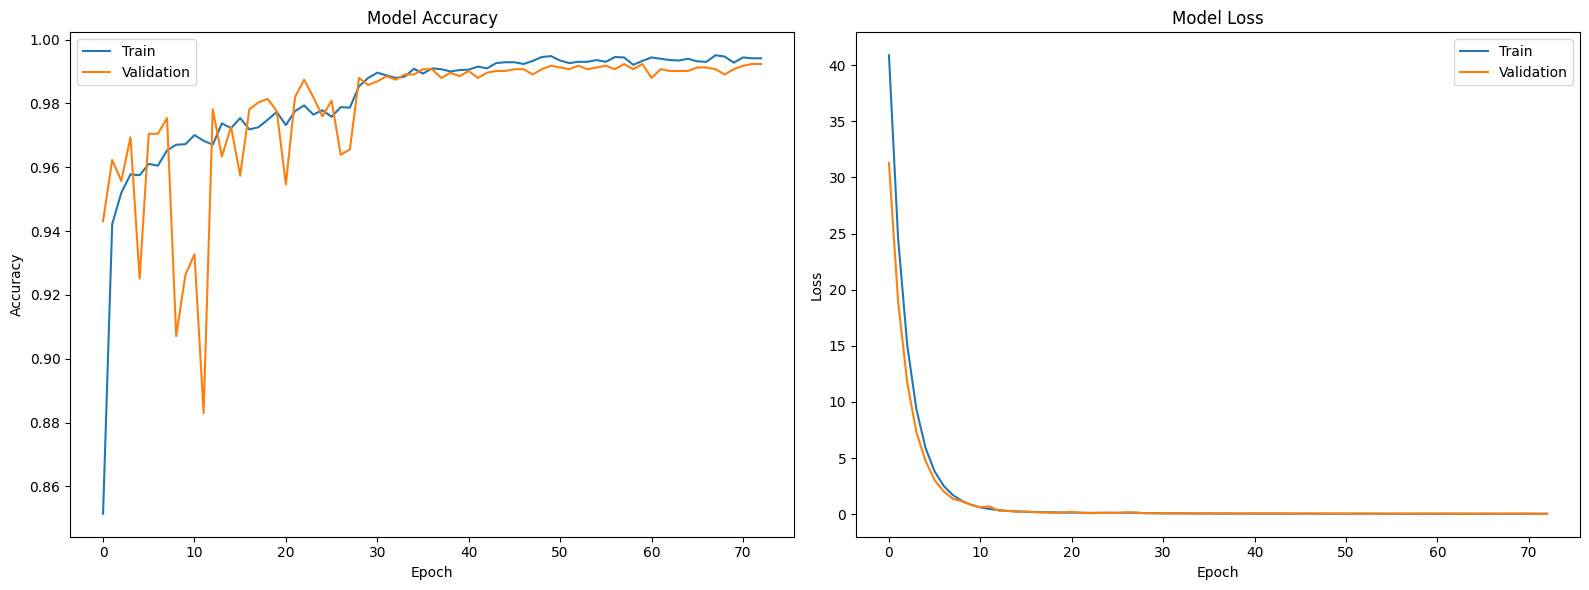

In [24]:
plt.figure(figsize=(16, 6))

# Accuracy history
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Loss history
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()


As we can see, our model starts to stabilize around the fourteenth epoch. However, since we implemented `ReduceLROnPlateau`, the training reduces the learning rate to around 10e-6 and goes into a very small fine-tuning state until `EarlyStopping` detects that it is not necessary to continue training, which stopped at epoch 79, but restored the weights from epoch 64.

### Classification report and confusion matrix

Let's create a function to plot both the classification report and the confusion matrix in the same figure.

In [14]:
def plot_conf_matrix_report(y_pred, y_test):
  plt.figure(figsize=(22, 8))

  # Subplot 1 - Classification Report
  plt.subplot(1, 2, 1)
  plt.title('Classification Report')
  clf_report = classification_report(y_test, y_pred, output_dict=True)
  report_df = pd.DataFrame(clf_report).iloc[:-1, :].T  # Remove 'support'
  sns.heatmap(report_df, annot=True, cmap='coolwarm', fmt=".2f")

  # Subplot 2 - Confusion Matrix
  plt.subplot(1, 2, 2)
  plt.title('Confusion Matrix')
  conf_matrix = confusion_matrix(y_test, y_pred)
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
  
  plt.tight_layout()
  plt.show()

Let's take advantage of `validation_generator`'s ability to release data in batches and create a special function to make predictions.

I really like using this functionality because it is useful for making predictions on large datasets.

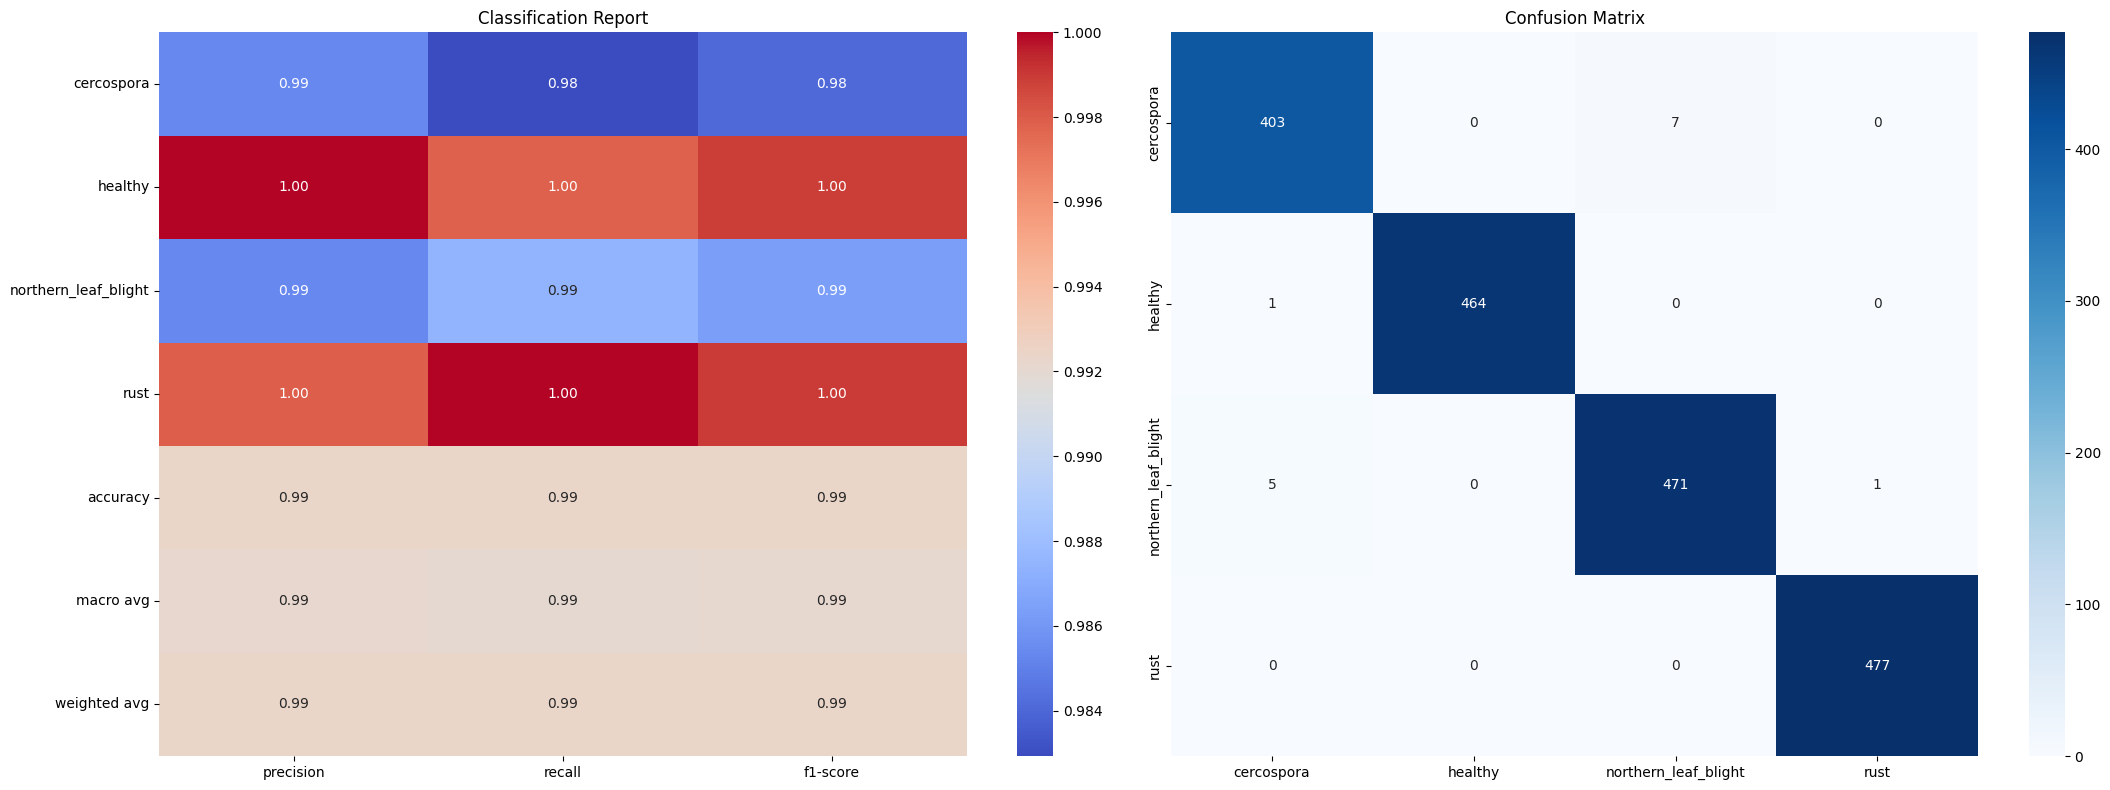

In [26]:
def evaluate_with_custom_generator(model, validation_generator):
	validation_generator.reset()

	# Lists to store results
	all_y_true = []
	all_y_pred = []

	# Iterate through all batches
	for i in range(len(validation_generator)):
		x, y = next(validation_generator)

		# Make predictions
		pred = model.predict(x, verbose=0)

		# Convert from one-hot to class index: [0, 1, 2, 3]
		# Since the output is softmax, we take the index of the highest value
		y_true_batch = np.argmax(y, axis=1)
		y_pred_batch = np.argmax(pred, axis=1)

		# Let's create a numpy-like function that applies to all elements of a numpy array
		# Converts from index to class name
		get_named_class = np.vectorize(lambda c: val_classes[c])

		# Store results
		all_y_true.extend(get_named_class(y_true_batch))
		all_y_pred.extend(get_named_class(y_pred_batch))

	return np.array(all_y_true), np.array(all_y_pred)


y_true, y_pred = evaluate_with_custom_generator(best_model, validation_generator)
plot_conf_matrix_report(y_pred, y_true)


# Results

Out of 1829 validation images, the trained model failed in only 14 cases, which represents only 0.76% of the dataset. Looking at the classification report, we can see that the f1-score was 0.98 or higher for all classes. Furthermore, we had an average of 0.99 for precision, recall and f1-score!

Given this successful training, we will soon save our model and test it visually.

In [16]:
def preprocess_image(path: str):
	# Load the image with the desired size
	img = load_img(path, target_size=IMG_SIZE)
	# Add RGB channels: img.shape = (224, 224, 3)
	img_arr = img_to_array(img)
	# Add batch dimension: img.shape = (1, 224, 224, 3)
	img_arr = np.expand_dims(img_arr, axis=0)
	img_arr = img_arr / 255.0
	return img_arr

def plot_results(data_class: str, num_images=8):
	selected_images = []
	for _ in range(num_images):
		class_path = os.path.join(val_path, data_class)
		image_choice = random.choice(os.listdir(class_path))  # Choose a random image
		image_path = os.path.join(class_path, image_choice)
		selected_images.append(image_path)

	predictions = []
	confidences = []
	for image in selected_images:
		img = preprocess_image(image)
		pred = best_model.predict(img, verbose=0)
		y_pred = np.argmax(pred, axis=1)[0]
		confidences.append(np.max(pred))  # Get the highest probability
		predictions.append(val_classes[y_pred]) 

	fig, axes = plt.subplots(1, num_images, figsize=(20, 4))

	for i, (image, prediction, confidence) in enumerate(zip(selected_images, predictions, confidences)):
		img = Image.open(image)  # Open the image
		img = img.resize(IMG_SIZE)  # Resize to maintain consistency
		axes[i].imshow(img)
		axes[i].set_title(f'{prediction}\nConfidence: {confidence*100:.1f}%')
		axes[i].axis('off')
		

	plt.suptitle(f'Predictions from folder {val_path}/{data_class}', fontsize=16)
	plt.tight_layout(rect=[0, 0, 1, 1.1]) 
	plt.show()


### Viewing predictions in the validation folder

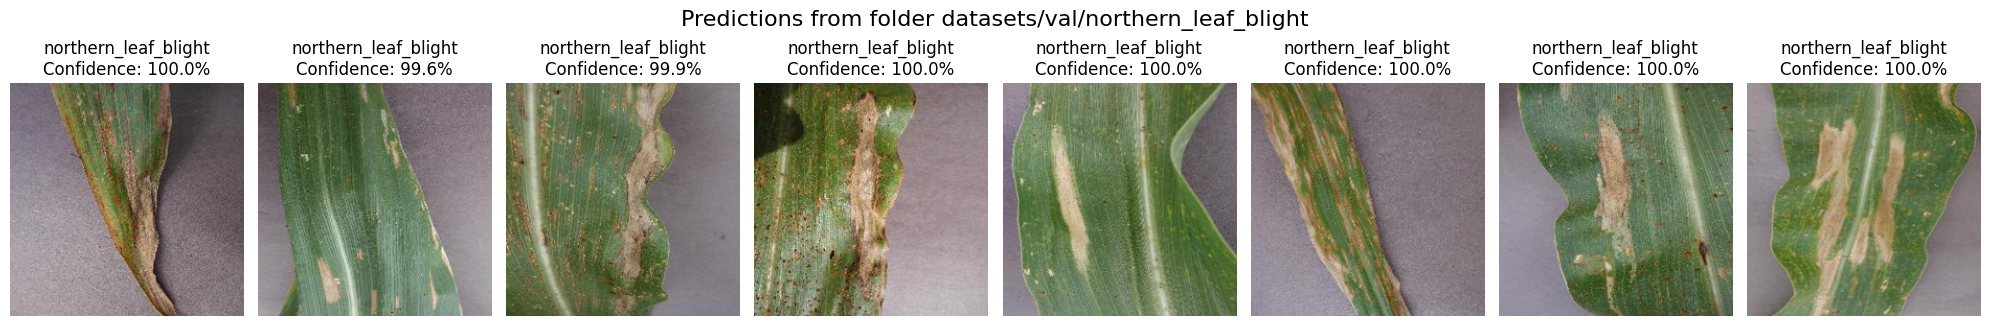

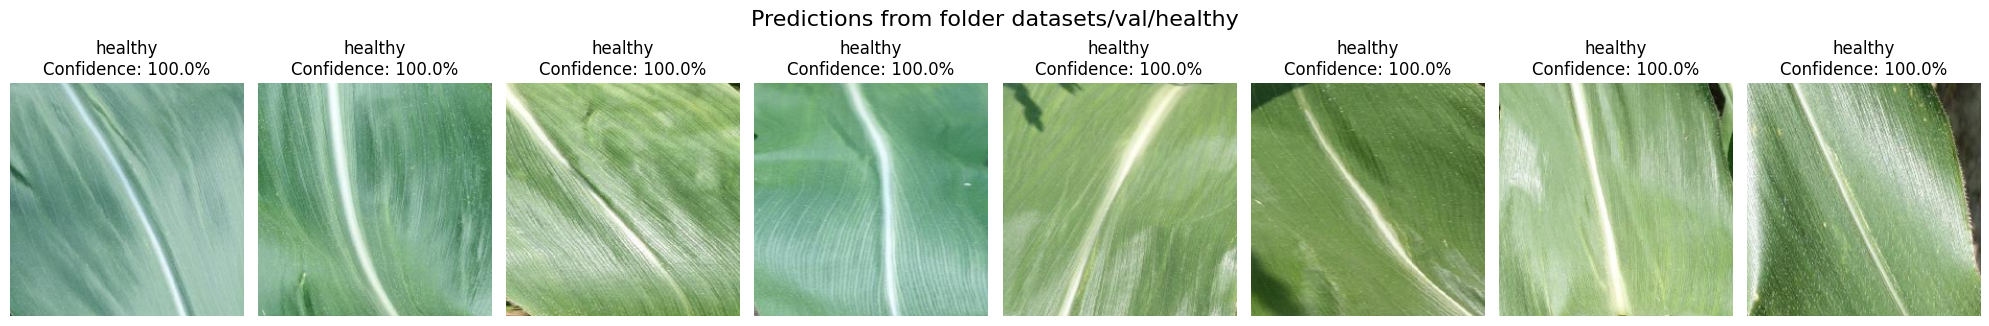

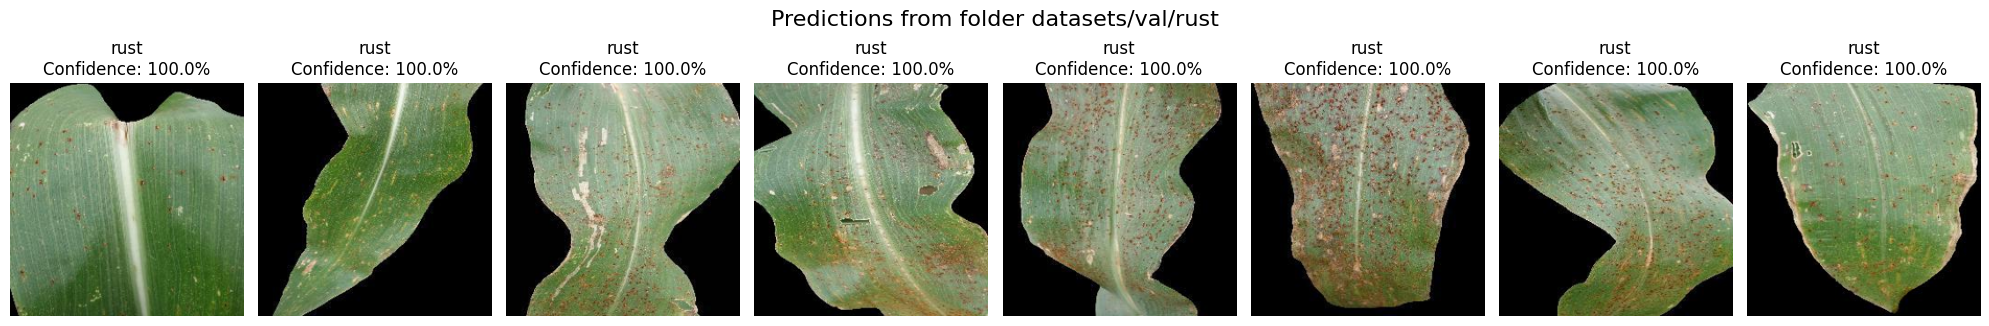

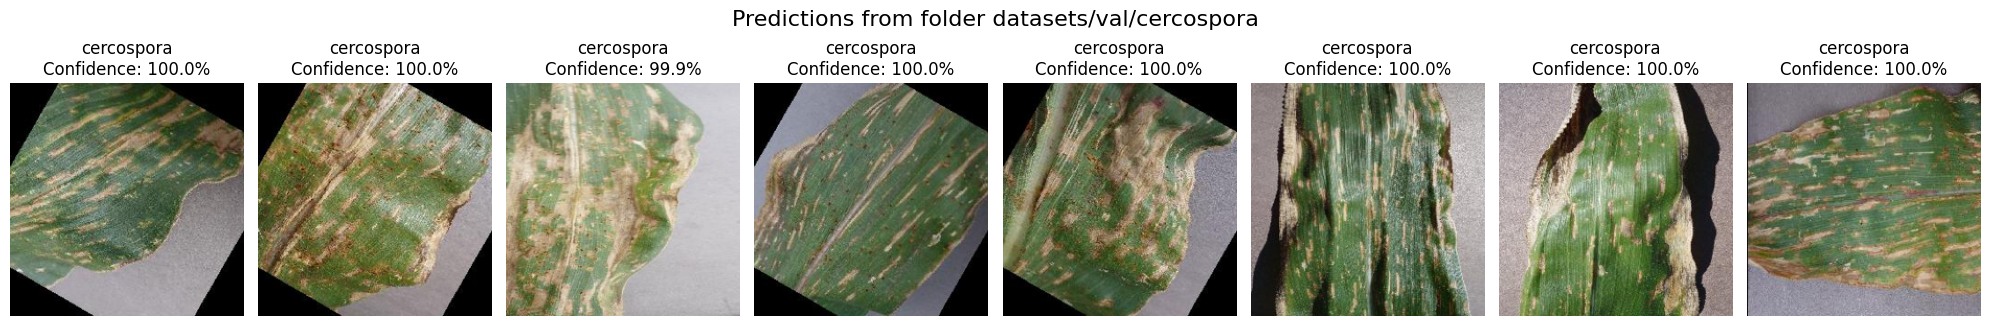

In [25]:
for class_name in val_classes:
	plot_results(class_name)

necessidade de estudar muito cada fungo e bactéria
estudar diferentes fases do fungo (entender o ciclo do fungo)
prevençâo e remediação das doenças
muita tentativa e erro
diagnósticos errados
prevenção é mais barato, portanto entender os estágios iniciais se torna crucial
prevenir fitotoxidade
para cada uma aplicacao curativa, só precisava de uma preventiva
para cada doença existe um volume de calda, tamanho da gota, proporcao de cobertura (molhar mais ou menos a folhagem)


### Using Grad-CAM

We will use Grad-CAM (Gradient-weighted Class Activation Mapping) to see how our model behaves during prediction. This is very useful to know how the techniques we employ affect the way the model performs.

In [18]:
def get_grad_cam(model, img_path):
    # Load and preprocess the image
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Remember to normalize as in training

    # Get the last convolutional layer
    for layer in reversed(model.layers):
        if isinstance(layer, Conv2D):
            layer_name = layer.name
            break

    # Create an intermediate model that outputs the target layer and model's final output
    grad_model = Model(inputs=model.input, outputs=[model.get_layer(layer_name).output, model.output])

    # Record operations with GradientTape
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)  # Forward pass
        class_index = np.argmax(predictions[0])  # Most probable class
        class_score = predictions[:, class_index]  # Score for that class

    # Compute the gradient of the class score with respect to conv layer outputs
    grads = tape.gradient(class_score, conv_outputs)

    # Take the mean of the gradients over each channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each conv channel by its corresponding gradient weight
    conv_outputs = conv_outputs[0]  # Remove batch dimension
    heatmap = np.dot(conv_outputs, pooled_grads[..., tf.newaxis])  # Ellipsis to add new dimension after others
    heatmap = tf.squeeze(heatmap)  # Remove extra dimensions of size 1

    # Normalize heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    return heatmap, class_index


def show_grad_cam(model, img_path):
    heatmap, class_index = get_grad_cam(model, img_path)
    predicted_class = val_classes[class_index]

    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)

    # Resize the heatmap to match the image size
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    # Superimpose the heatmap on the original image (50% transparency)
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap_colored, 0.4, 0)
    
    # Convert from BGR (used by cv2) to RGB (used by matplotlib)
    superimposed_img = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)

    # Plot the image with heatmap
    plt.figure(figsize=(8, 5))
    
    plt.subplot(1, 2, 1)
    plt.title('Original Image')
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title('Heatmap')
    plt.axis('off')
    
    plt.suptitle(f'Grad-CAM: {predicted_class}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.98]) 
    plt.show()


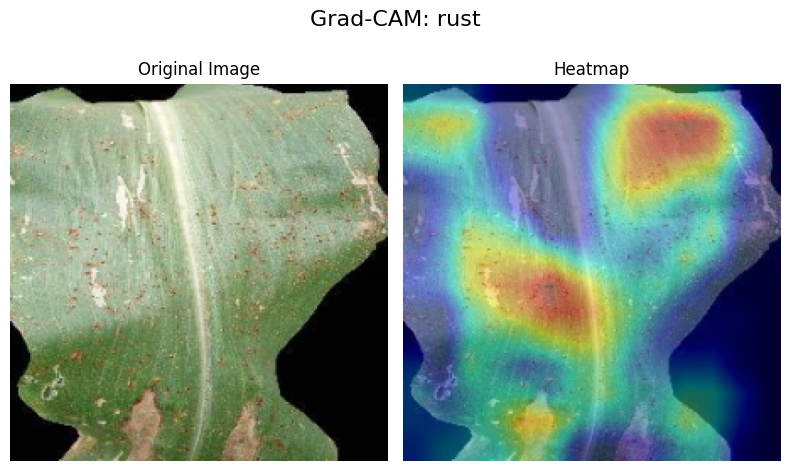

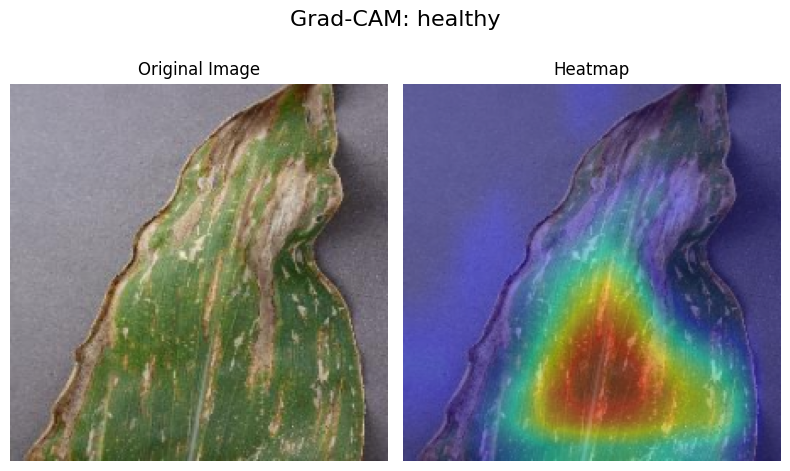

In [ ]:
show_grad_cam(best_model, 'datasets/val/rust/RS_Rust 1626_flipLR.JPG')
show_grad_cam(best_model, 'datasets/val/cercospora/0ba90f90-3702-438a-908b-85871f3a34cb___RS_GLSp 4342.JPG')